## Objective

- Load and explore the Boston Housing dataset.
- Prepare input features and target values for regression modeling.
- Split the data into training and testing sets.
- Standardize the feature values.
- Build and train a neural network model to predict house prices.
- Evaluate model performance using MSE and R² score.
- Visualize training loss and actual vs. predicted values.
- Experiment with different epoch values and neuron configurations to compare model performance.

In [1]:
import pandas as pd


In [2]:
url = "https://raw.githubusercontent.com/iPriyadarshi/MachineLearning-BCS4706/main/dataset/BostonHousing.csv"
df = pd.read_csv(url)


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [4]:
df.describe()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [5]:
df.head()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
X = df.iloc[:,0:11]
y = df.iloc[:,13]


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
print(y_test)


173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
       ... 
412    17.9
436     9.6
411    17.2
86     22.5
75     21.4
Name: medv, Length: 102, dtype: float64


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [10]:
X_train.shape[1]


11

In [11]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()

model.add(Dense(100,activation='relu',input_dim=11))
model.add(Dense(30,activation='relu'))
model.add(Dense(1))


C:\Users\Priyadarshi_Kumar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    loss="mse",
    optimizer="adam",
    metrics=["mse"]
)


In [13]:
history = model.fit(X_train,y_train,validation_split=0.2,epochs=300,batch_size=16)


Epoch 1/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 603.4421 - mse: 603.4421 - val_loss: 509.1213 - val_mse: 509.1213
Epoch 2/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 520.4489 - mse: 520.4489 - val_loss: 423.8383 - val_mse: 423.8383
Epoch 3/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 407.6593 - mse: 407.6593 - val_loss: 299.0721 - val_mse: 299.0721
Epoch 4/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 259.7063 - mse: 259.7063 - val_loss: 161.5421 - val_mse: 161.5421
Epoch 5/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 134.3972 - mse: 134.3972 - val_loss: 72.0089 - val_mse: 72.0089
Epoch 6/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 77.1869 - mse: 77.1869 - val_loss: 42.7655 - val_mse: 42.7655
Epoch 7/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 52.8699 - mse: 52.8699 - val_loss: 34.0763 - val_mse: 34.0763
Epoch 8/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 41.6295 - mse: 41.6295 - val_loss: 30.3314 - val_mse: 30.3314
Epoch 9/300
2

In [14]:
history.history['loss']


[603.4420776367188,
 520.4488525390625,
 407.6593322753906,
 259.706298828125,
 134.39723205566406,
 77.18685150146484,
 52.86989212036133,
 41.62948226928711,
 35.36185836791992,
 31.91937828063965,
 29.75872230529785,
 28.535600662231445,
 27.155195236206055,
 26.09071159362793,
 25.27426528930664,
 24.23969841003418,
 23.56595802307129,
 22.77485466003418,
 22.2581729888916,
 21.65443992614746,
 21.068384170532227,
 20.60698890686035,
 20.382600784301758,
 19.708393096923828,
 19.41590690612793,
 19.10369300842285,
 18.643569946289062,
 18.382890701293945,
 18.030790328979492,
 18.032596588134766,
 17.881263732910156,
 17.57386016845703,
 17.206157684326172,
 17.083972930908203,
 16.94455909729004,
 16.78358268737793,
 16.60474395751953,
 16.7614803314209,
 16.17523193359375,
 16.98834800720215,
 15.988286018371582,
 16.1368465423584,
 15.858773231506348,
 15.859504699707031,
 15.57429313659668,
 15.856865882873535,
 15.302651405334473,
 15.268980979919434,
 15.431715965270996,
 15.

In [15]:
y_pred = model.predict(X_test)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [16]:
print(y_pred)


[[29.958258]
 [34.353294]
 [18.217138]
 [24.623585]
 [17.82008 ]
 [21.732391]
 [17.803812]
 [17.886002]
 [27.620327]
 [19.643036]
 [22.347301]
 [20.240242]
 [ 3.106433]
 [20.331419]
 [18.011303]
 [20.971848]
 [18.597233]
 [11.76297 ]
 [46.860004]
 [12.566265]
 [26.018606]
 [26.676092]
 [14.417604]
 [23.635584]
 [13.729923]
 [24.607115]
 [21.152073]
 [13.623838]
 [19.659306]
 [19.406471]
 [25.097775]
 [24.638435]
 [17.936129]
 [28.853968]
 [25.062368]
 [16.397154]
 [32.416725]
 [20.177938]
 [21.755644]
 [24.436749]
 [18.808186]
 [31.123362]
 [51.762974]
 [18.114578]
 [27.590538]
 [13.455148]
 [14.3344  ]
 [25.45779 ]
 [19.644142]
 [23.059101]
 [20.59942 ]
 [34.68048 ]
 [15.198233]
 [25.731045]
 [43.044243]
 [20.913029]
 [17.519724]
 [31.39472 ]
 [26.463152]
 [18.833412]
 [26.590622]
 [35.47507 ]
 [30.356342]
 [20.92527 ]
 [24.694725]
 [20.662334]
 [12.210148]
 [23.76065 ]
 [27.917513]
 [19.828657]
 [21.76393 ]
 [22.798574]
 [ 9.362604]
 [18.118626]
 [22.735304]
 [ 8.25683 ]
 [19.74546 ]

In [17]:
y_pred = y_pred.flatten()


In [18]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)


Mean Squared Error (MSE): 23.99714993459924
R2 Score: 0.6727681444971076


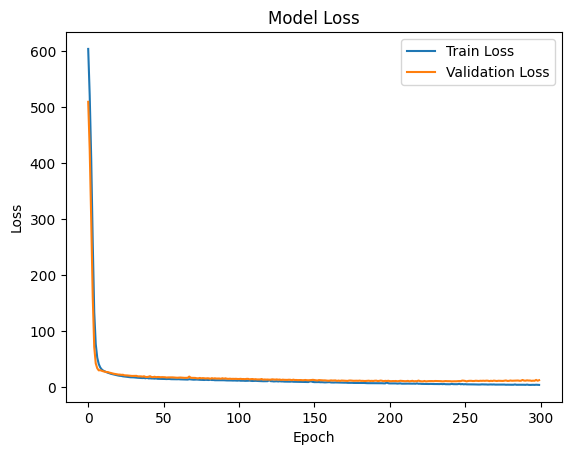

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Validation Loss"])
plt.show()


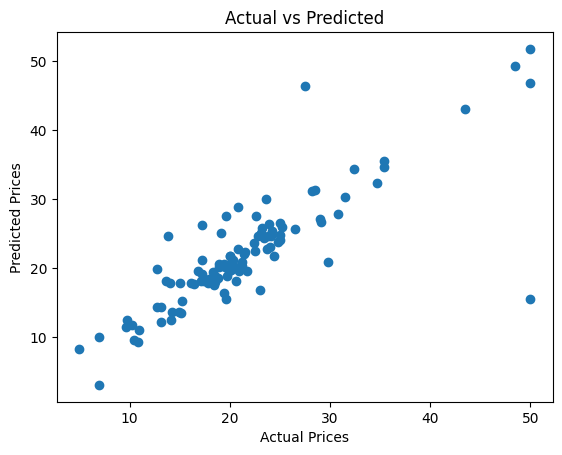

In [20]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()


## Experimenting with various values of epochs and changing number of neurons

In [21]:
epoch_list = [100, 300, 500]
neuron_configs = [
    (50, 20),
    (100, 30),
    (150, 50)
]


In [22]:
results = []


In [23]:
for epochs in epoch_list:
    for n1, n2 in neuron_configs:
        print(f"Training: epochs={epochs}, neurons=({n1},{n2})")

        model = Sequential()
        model.add(Dense(n1, activation='relu'))
        model.add(Dense(n2, activation='relu'))
        model.add(Dense(1))

        model.compile(
            loss="mse",
            optimizer="adam",
            metrics=["mse"]
        )

        history = model.fit(
            X_train, y_train,
            validation_split=0.2,
            epochs=epochs,
            batch_size=16,
            verbose=0
        )

        y_pred = model.predict(X_test).flatten()

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "epochs": epochs,
            "neurons": f"{n1}-{n2}",
            "mse": mse,
            "r2": r2,
            "history": history.history
        })


Training: epochs=100, neurons=(50,20)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Training: epochs=100, neurons=(100,30)
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000276B9279580> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Training: epochs=100, neurons=(150,50)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Traini

In [24]:
# convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)


   epochs neurons        mse        r2  \
0     100   50-20  18.372574  0.749466   
1     100  100-30  17.257164  0.764676   
2     100  150-50  17.647401  0.759355   
3     300   50-20  22.620313  0.691543   
4     300  100-30  24.948923  0.659789   
5     300  150-50  26.087344  0.644266   
6     500   50-20  20.736675  0.717229   
7     500  100-30  26.454552  0.639258   
8     500  150-50  27.097371  0.630493   

                                             history  
0  {'loss': [562.5873413085938, 504.2223815917969...  
1  {'loss': [600.7142944335938, 536.1652221679688...  
2  {'loss': [564.506103515625, 432.0706787109375,...  
3  {'loss': [588.0836791992188, 546.4560546875, 4...  
4  {'loss': [598.3788452148438, 537.8818359375, 4...  
5  {'loss': [578.1332397460938, 465.6930236816406...  
6  {'loss': [578.88037109375, 519.7174072265625, ...  
7  {'loss': [549.9677734375, 429.3770751953125, 2...  
8  {'loss': [559.4752807617188, 402.8279418945312...  


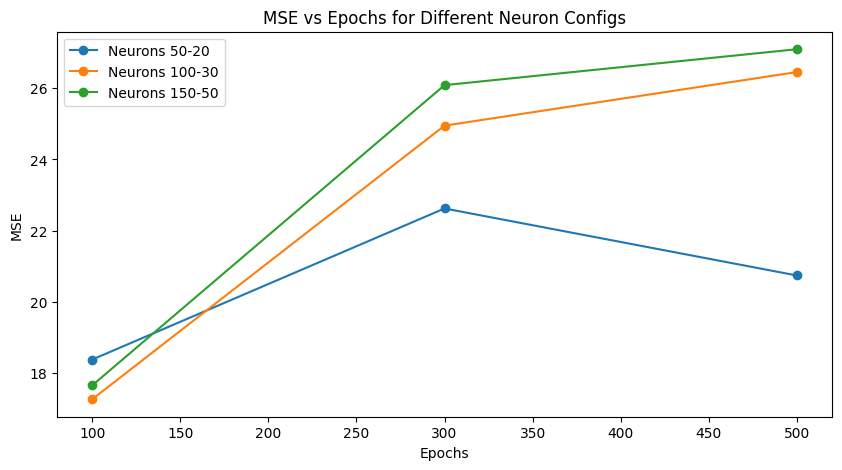

In [25]:
plt.figure(figsize=(10,5))
for neurons in results_df["neurons"].unique():
    subset = results_df[results_df["neurons"] == neurons]
    plt.plot(subset["epochs"], subset["mse"], marker='o', label=f"Neurons {neurons}")

plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("MSE vs Epochs for Different Neuron Configs")
plt.legend()
plt.show()


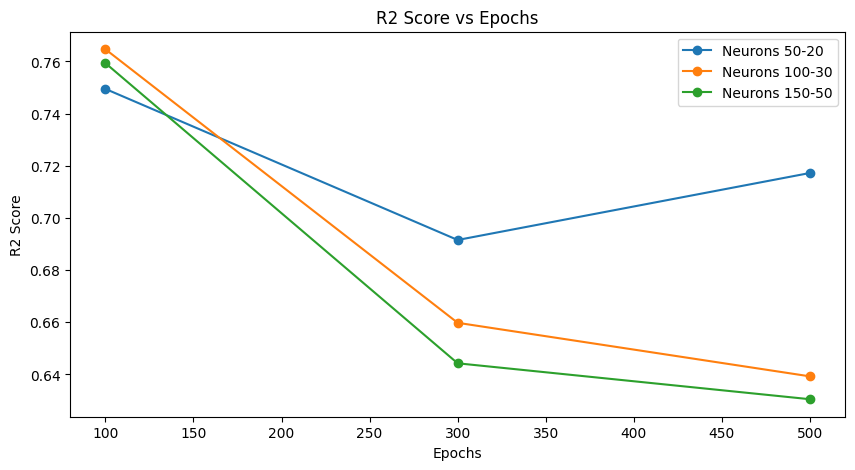

In [26]:
plt.figure(figsize=(10,5))
for neurons in results_df["neurons"].unique():
    subset = results_df[results_df["neurons"] == neurons]
    plt.plot(subset["epochs"], subset["r2"], marker='o', label=f"Neurons {neurons}")

plt.xlabel("Epochs")
plt.ylabel("R2 Score")
plt.title("R2 Score vs Epochs")
plt.legend()
plt.show()


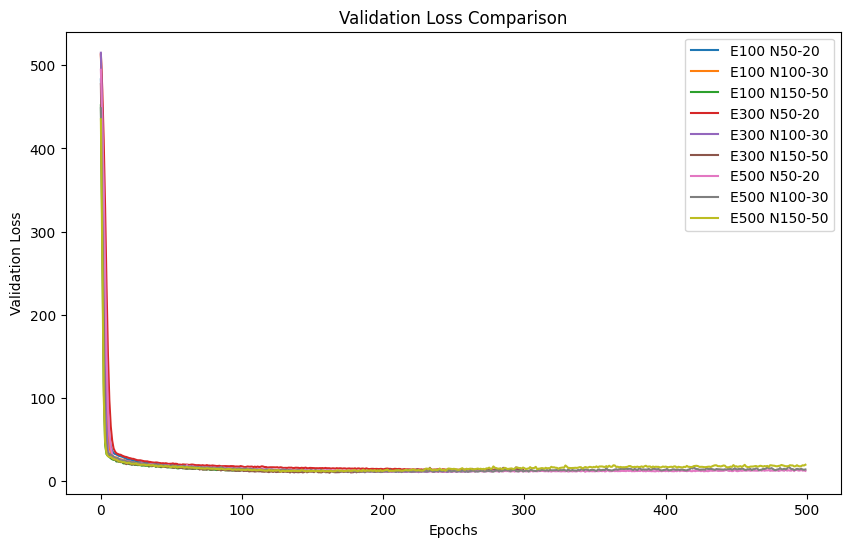

In [27]:
plt.figure(figsize=(10,6))

for res in results:
    label = f"E{res['epochs']} N{res['neurons']}"
    plt.plot(res["history"]["val_loss"], label=label)

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()
